# Exploring the stochastic world of SGD - Comparative Analysis

In this notebook, we compare the stochastic properties of **Stochastic Gradient Descent (SGD)** with those of other stochastic optimization techniques, both from a theoretical perspective and through empirical evaluation.

The goal is to highlight how different sources of randomness and update mechanisms influence the optimization dynamics.

By combining analytical insights with experimental results, we aim to better understand the similarities and differences between SGD and alternative stochastic optimization strategies.

This notebook is divided into three main parts:

1. **Other Stochastic Optimization Techniques**

   Overview and discussion of alternative stochastic optimization methods.

2. **Theoretical Comparison**

   Analytical comparison of SGD with other stochastic optimization approaches in terms of their update rules and induced stochastic behavior.

3. **Empirical Comparison**

   Experimental evaluation of the different methods and comparison of their observed stochastic properties in practice.

# Other Stochastic Optimization Techniques

In this section, we explore the formulation of several stochastic optimization techniques. The focus is not primarily on their optimization performance, but rather on the stochastic mechanisms underlying their dynamics. We will also introduce a somewhat novel optimization procedure, designed not necessarily to outperform existing methods, but to provide a simpler framework for studying stochastic optimization processes.

Note : all the algorithms implementation are standars implementations. You can find more on the internet.

## SGD

We just report the standard SGD implementation with gaussian isotropic noise as proxy for the batch noise.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [2]:
def sgd(f, grad_f, x0, n_steps, lr=0.01, grad_sigma=0.5, seed = None):

    np.random.seed(seed)

    x = np.array(x0, dtype=float)
    
    x_hist = [x.copy()]
    f_hist = [f(x)]

    for _ in range(n_steps):

        g = grad_f(x) 

        x = x - lr * g - lr * np.random.normal(loc = 0, scale = grad_sigma, size = len(x)) # adding some random noise to simulate batch noise

        x_hist.append(x.copy())
        f_hist.append(f(x))

    return np.array(x_hist), np.array(f_hist)

## Momentum SGD

The first optimization technique we analyze is **Momentum Stochastic Gradient Descent (Momentum SGD)**. We consider it not only because of its practical effectiveness, but also because it introduces the important concept of jointly evolving a *position* and a *velocity* variable.

The standard Momentum SGD update is

$$
v_{t+1} = \beta v_t + (1-\beta)\nabla f(x_t),
$$

$$
x_{t+1} = x_t - \eta v_{t+1},
$$

where $\beta\in[0,1)$ is the momentum coefficient and $\eta$ is the learning rate.

Looking at the velocity update, one can recursively expand the update:

$$
v_{t+1} = \beta (\beta (v_{t-1} + (1 - \beta)\nabla f(x_{t-1}))) + (1 - \beta)\nabla f(x_{t})
= \beta^2v_{t-1} + \beta(1-\beta)\nabla f(x_{t-1}) + (1 - \beta)\nabla f(x_{t}).
$$

Continuing the expansion yields

$$
v_{t+1} = \beta^t v_1 + \sum_{k=1}^t \beta^{t-k}(1 - \beta)\nabla f (x_k)
$$

This expression shows that the velocity is an exponentially weighted moving average of past gradients. A gradient computed $$m$$ iterations ago contributes a weight proportional to $$\beta^m$$. Consequently, older gradients have an exponentially decreasing influence on the update.

The parameter $\beta$ therefore determines the effective memory of the optimizer. A useful heuristic is obtained by noting that the weights decay on a characteristic timescale of approximately

$$
\tau \sim \frac{1}{1 - \beta}
$$

Thus, $\beta = 0.9$ corresponds to an effective memory of roughly $10$ iterations, while $\beta = 0.99$ corresponds to roughly $100$ iterations. Larger values of $\beta$ produce smoother updates by averaging gradients over longer time horizons, whereas smaller values place greater emphasis on recent gradient information.

From this perspective, momentum acts as a low-pass filter on the stochastic gradient noise, reducing short-term fluctuations while preserving persistent descent directions.

In [3]:
def momentum_sgd(f, grad_f, x0, n_steps,lr=0.01, beta=0.9, grad_sigma=0.5, seed = None):

    np.random.seed(seed)

    x = np.array(x0, dtype=float)
    v = np.zeros_like(x)

    x_hist = [x.copy()]
    f_hist = [f(x)]

    for _ in range(n_steps):

        g = grad_f(x) + np.random.normal(loc = 0, scale = grad_sigma, size = len(x)) # adding some random noise to simulate batch noise

        v = beta * v + (1 - beta) * g
        x = x - lr * v

        x_hist.append(x.copy())
        f_hist.append(f(x))

    return np.array(x_hist), np.array(f_hist)

## Simulated Annealing

**Simulated Annealing (SA)** is a classical stochastic optimization technique with the remarkable theoretical property that, under suitable conditions, it converges to a global optimum. Although this asymptotic guarantee is rarely relevant in practical machine-learning settings, it makes SA one of the most studied stochastic optimization algorithms.

Unlike Gradient Descent and its variants, Simulated Annealing does not use gradient information. Instead, it relies solely on function evaluations. While it is often presented as a method for direct function optimization, it can also be applied to parameter optimization problems by viewing the objective as a function over the parameter space.

At iteration $t$, a candidate point $x'$ is generated from the current point $x_t$ through a random perturbation. The candidate is accepted according to the Metropolis criterion:

$$
P(\text{accept}) =
\begin{cases}
1, & f(x') < f(x_t), \\
\exp\left(-\frac{f(x')-f(x_t)}{T_t}\right), & f(x') \geq f(x_t),
\end{cases}
$$

where $T_t$ is the temperature parameter. As the temperature decreases, the probability of accepting worse solutions becomes smaller.

A classical convergence theorem due to Geman and Geman states that if the temperature decreases sufficiently slowly, for example according to a logarithmic schedule

$$
T_t = \frac{c}{\log(1+t)},
$$

then the algorithm converges in probability to the set of global minima.

Some researcher tried to frame Simulated Annealing in continuous spaces as a stochastic differential equation of the form

$$
dX_t = -\nabla f(X_t)dt + \sqrt{2T(t)}\, dW_t,
$$

where $W_t$ is a Wiener process. The deterministic drift term drives the dynamics toward lower objective values, while the stochastic term injects noise whose magnitude is controlled by the temperature. As the temperature decreases, the dynamics gradually transition from exploration to exploitation.

By the way this SDE is assuming that the perturbation are somehow forced to assume a gradient-like + gaussian noise form, which can be a strong assumption.

In [4]:
def simulated_annealing(f, x0, bounds, n_steps, T0=1.0, alpha=0.995, seed = None):

    np.random.seed(seed)
    
    x = np.array(x0, dtype=float)

    low_bounds = np.array([b[0] for b in bounds])
    high_bounds = np.array([b[1] for b in bounds])

    best_x = x.copy()
    best_f = f(x)

    x_hist = [x.copy()]
    f_hist = [best_f]

    T = T0

    for _ in range(n_steps):

        proposal = x + np.sqrt(2*T) * np.random.normal(0, 1, x.shape)
        proposal = np.clip(proposal, low_bounds, high_bounds)

        fx = f(x)

        delta = f(proposal) - fx

        if delta < 0:
            accept = True
        else:
            accept = np.random.rand() < np.exp(-delta / T)

        if accept:
            x = proposal

        if fx < best_f:
            best_f = fx
            best_x = x.copy()

        T *= alpha

        x_hist.append(x.copy())
        f_hist.append(fx)

    return np.array(x_hist), np.array(f_hist)

## Particle Swarm Optimization

**Particle Swarm Optimization (PSO)** belongs to the family of bio-inspired optimization methods known as *swarm intelligence*. The individual particles are simple agents with limited capabilities; complex and adaptive behaviour emerges from their collective interactions.

In the most common global-best formulation, each particle maintains a position $x_i$ and a velocity $v_i$. The update equations are

$$
v_i^{t+1}=\omega v_i^t+c_1 r_1 (p_i - x_i^t)+c_2 r_2 (g - x_i^t),
$$

$$
x_i^{t+1} = x_i^t + v_i^{t+1},
$$

where $p_i$ is the personal best position found by particle $i$, $g$ is the best position found by the swarm, $\omega$ is the inertia coefficient, and $r_1,r_2\sim U(0,1)$ are random variables. Many variants exist, including local-best, constriction-factor, and adaptive PSO formulations.

The stochasticity of PSO originates from the random coefficients multiplying the attraction terms. Unlike SGD, where randomness is typically induced by stochastic gradient estimates, PSO injects randomness directly into the dynamics of the search trajectory.

Several works have attempted to derive continuous-time and stochastic differential equation representations of PSO. While such formulations provide useful theoretical insight, the resulting models are considerably more complex than those arising for SGD because of the coupling between particles and the dependence on personal and global best states.

Motivated by these observations, we will later introduce a PSO-inspired variant based on a single particle. The idea is to simulate the effect of a swarm by randomly sampling candidate attractors and moving toward them, thereby preserving some of the stochastic characteristics of PSO while remaining easier to analyze theoretically.

In [5]:
def pso(f, bounds, n_particles=30, n_steps=500, w=0.7, c1=1.5, c2=1.5, seed = None):

    np.random.seed(seed)

    low_bounds = np.array([b[0] for b in bounds])
    high_bounds = np.array([b[1] for b in bounds])

    X = np.array([
        np.random.uniform(low, high, n_particles)
        for low, high in bounds
    ]).T

    V = np.zeros_like(X)

    P = X.copy()
    P_val = np.array([f(x) for x in P])

    g_idx = np.argmin(P_val)
    G = P[g_idx].copy()

    best_history = []
    x_best_history = []

    for _ in range(n_steps):

        r1 = np.random.rand(*X.shape)
        r2 = np.random.rand(*X.shape)

        V = (
            w * V
            + c1 * r1 * (P - X)
            + c2 * r2 * (G - X)
        )

        X = X + V

        out_of_low = X < low_bounds
        out_of_high = X > high_bounds
        
        X = np.clip(X, low_bounds, high_bounds)
        
        V[out_of_low | out_of_high] = 0.0 # zeroing velocity when hitting the boundaries

        values = np.array([f(x) for x in X])

        improved = values < P_val
        P[improved] = X[improved]
        P_val[improved] = values[improved]

        G = P[np.argmin(P_val)].copy()

        best_history.append(np.min(P_val))
        x_best_history.append(G)

    return np.array(x_best_history), np.array(best_history)

## Sad Particle (Highly) Hallucinating Friends 

To better isolate the stochastic mechanisms underlying Particle Swarm Optimization (PSO), we introduce a simplified toy algorithm that we call the Sad Particle Hallucinating Friends (SPHF) algorithm.

The algorithm consists of a single particle attempting to minimize an objective function $f$. Unlike standard PSO, there is no actual swarm. However, the particle is lonely and therefore hallucinates the existence of other particles at every iteration.

Let $x_t$ denote the current position of the particle and $v_t$ its velocity. At each iteration, the particle generates $N$ hallucinated friends whose positions are sampled from a distribution $q_t$:

$$
y_t^{(1)}, \ldots, y_t^{(N)} \sim q_t.
$$

The objective function is evaluated at these locations, and the particle identifies the best hallucinated position taking in consideration the best solution found from the friends so far

$$
g_t = \arg\min_{y \in {y_t^{(1)},\ldots,y_t^{(N)}, g_{t-1}}} f(y).
$$

As in standard PSO, the particle also maintains its personal best position

$$
p_t = \arg\min_{0 \leq s \leq t} f(x_s).
$$

The velocity update is then given by

$$
v_{t+1} = w v_t + c_1 r_{1,t}(p_t - x_t) + c_2 r_{2,t}(g_t - x_t),
$$

where $w$ is the inertia coefficient, $c_1$ and $c_2$ are attraction parameters, and $r_{1,t}, r_{2,t}\sim U(0,1)$ are independent random variables.

The position is updated according to

$$
x_{t+1}=x_t+v_{t+1}.
$$

The key difference from standard PSO is that the global-best term does not originate from information exchanged within a real swarm. Instead, it is generated through repeated random hallucinations of neighboring particles. Consequently, all stochasticity arises from two sources: the random coefficients $r_{1,t}$ and $r_{2,t}$, and the random generation of hallucinated friends.

Although SPHF is not intended as a competitive optimization algorithm, it provides a convenient framework for studying how attraction toward randomly generated candidate solutions influences optimization dynamics. In particular, it separates the effects of swarm interaction from the effects of stochastic exploration, making the resulting process easier to analyze than a full particle swarm.

For the code implementation we will use $q_t = \mathcal{U}(-10, 10)$, which is why this version is called "Highly Hallucinating", since it does not use any prior information about where the sad point actually is.

In [6]:
def sphf(f, x0, bounds, n_steps, n_friends=5, w=0.7, c1=1.5, c2=1.5, min_v = -1, max_v = 1, seed = None):

    np.random.seed(seed)

    low_bounds = np.array([b[0] for b in bounds])
    high_bounds = np.array([b[1] for b in bounds])
    
    x = np.array(x0)
    v = np.zeros_like(x)

    p = x.copy()
    p_val = f(x)
    g = None

    x_hist = [x.copy()]
    f_hist = [p_val.copy()]

    for _ in range(n_steps):
        # Sample friends uniformly
        friends = np.random.uniform(low_bounds, high_bounds, size=(n_friends, len(bounds)))

        friend_values = np.array([f(friend) for friend in friends])

        best_friend_idx = np.argmin(friend_values)
        best_friend_val = friend_values[best_friend_idx]
        best_friend_pos = friends[best_friend_idx]

        if g is None:
            g = best_friend_pos.copy()
            g_val = best_friend_val
        elif best_friend_val < g_val:
            g = best_friend_pos.copy()
            g_val = best_friend_val

        r1 = np.random.rand(*x.shape)
        r2 = np.random.rand(*x.shape)

        v_next = w * v + c1 * r1 * (p - x) + c2 * r2 * (g - x)

        v = np.clip(v_next, min_v, max_v)

        x = np.clip(x + v, low_bounds, high_bounds)

        if np.any(x == low_bounds) or np.any(x == high_bounds): #zeroing velocity when hitting a border
            v = np.zeros_like(v)

        value = f(x)
        
        if value < p_val:
            p = x.copy()
            p_val = value

        x_hist.append(x.copy())
        f_hist.append(value)

    return np.array(x_hist), np.array(f_hist)

# Theoretical Comparison

To highlight the various differences between those optimization techniques, we report this theoretical summary table.

|Algorithm|Source of Randomness|Search Scope|Gradient Dependent?|
|:--      |:--                 |:--         |:--                |
|SGD| Data mini-batching (sampling noise, simulated by gaussian noise) |Local (Gradient-driven)|Yes|
|Momentum SGD| Accumulated data mini-batching (sampling noise, simulated by gaussian noise) |Local (Gradient-driven)|Yes|
|Simulated Annealing|Proposal distribution step|Local → Global|No|
|PSO|"Random acceleration coefficients (r1​,r2​)"|Global (Collective)|No|
|SPHF|Coefficients + Hallucination sampling|Local/Global (Dependent on sampling)|No|

From this summary we can already imagine how the SGD is weaker then other methods on the exploration side. 

# Empirical Comparison

We will compare the effectivness of the previous algorithms on some landscapes.

There will be some low dimensional landscapes where we will also visualize the different dynamics, while there will be some other landscapes where there only will be the numerical results to rely on.

## Bounded 1D Linear Increasing Cosine Function

This landscape seems pretty trivial as it is, but it is useful to stress out the main difficulties of SGD, the exploration.

$$f(x) = x \cos(x) + 0.1x$$

Working on the unbounded version has no maximum or minimum, since the limit of the function are undefined but it obviously oscillates over $\pm \infty$.

The bounded version constraint the search to $[-10, 10]$. It has several local minimum, and a global minimum approximatelly in $x = 9.51899$.

In [7]:
# Define the function
def lic(x):
    return x*np.cos(x) + 0.1*x
# Define the gradient (which in this case is just the derivative) for the SGD
def grad_lic(x):
    return np.array(np.cos(x) - x*np.sin(x) + 0.1)

In [8]:
n_steps = 50
bounds = [[-10, 10]]
x0 = [[0] for _ in range (4)]
seed = 37

# SGD0
sgd_x, sgd_f = sgd(lic, grad_lic, x0=x0[0], n_steps=n_steps, grad_sigma=1, lr=0.05, seed=seed)

# Momentum SGD
msgd_x, msgd_f = momentum_sgd(lic, grad_lic, x0=x0[1], n_steps=n_steps, grad_sigma=1, lr = 0.05, seed = seed)

# Simulated Annealing
sa_x, sa_f = simulated_annealing(lic, x0=x0[2], n_steps=n_steps, bounds=bounds, seed = seed)

# PSO
pso_x, pso_f = pso(lic, bounds=bounds, n_particles=10, n_steps=n_steps, seed = seed)

# SPHF
sphf_x, sphf_f = sphf(lic, x0=x0[3], bounds=bounds, n_steps=n_steps, seed = seed)

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
x_vals = np.linspace(-10, 10, 500)
y_vals = lic(x_vals)

ax.plot(x_vals, y_vals, color='gray', linestyle='--', alpha=0.6, label='LIC Objective')

dot_sgd, = ax.plot([], [], 'yo', markersize=8, label='SGD')
dot_msgd, = ax.plot([], [], 'ro', markersize=8, label='Momentum SGD')
dot_sa,   = ax.plot([], [], 'go', markersize=8, label='Simulated Annealing')
dot_pso,  = ax.plot([], [], 'bo', markersize=8, label='PSO (Global Best)')
dot_sphf, = ax.plot([], [], 'mo', markersize=10, label='SPHF (Lonely Particle)')

ax.set_xlim(-10, 10)
ax.set_ylim(np.min(y_vals) - 2, np.max(y_vals) + 2)
ax.set_xlabel("Parameter Space (x)")
ax.set_ylabel("Objective Value f(x)")
ax.set_title("Stochastic Optimization Trajectories over Time")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

def update(frame):
    gx = sgd_x[frame][0]
    mx = msgd_x[frame][0]
    sx = sa_x[frame][0]
    px = pso_x[frame][0]
    shx = sphf_x[frame][0]
    
    dot_sgd.set_data([gx], [lic(gx)])
    dot_msgd.set_data([mx], [lic(mx)])
    dot_sa.set_data([sx], [lic(sx)])
    dot_pso.set_data([px], [lic(px)])
    dot_sphf.set_data([shx], [lic(shx)])
    
    return dot_sgd, dot_msgd, dot_sa, dot_pso, dot_sphf

ani = FuncAnimation(fig, update, frames=n_steps, blit=True, interval=150)
plt.close(fig)

#HTML(ani.to_jshtml())
# ani.save("../figures/comp_cosine.gif", writer="pillow", fps=20)

## Bounded 2D Rastrigin

This landscape is highly non-convex with a massive number of regularly distributed local minima. The 2-dimensional form is

$$
f(x, y) = 20 + (x^2 - 10\cos(2\pi x)) + (y^2 - 10\cos(2\pi y))
$$

We bound the search in the domain $[-5.12, 5.12] \times [-5.12, 5.12]$. The global minimum is located in $(0, 0)$ with a value of $0$.

The higher-dimensional generalisation is

$$
f(x) = 10D + \sum_{i=1}^D (x_i^2-10cos(2\pi x_i))
$$

With $x \in \mathbb{R}^D$. The global minimum still remains in $\vec 0$ with a value of $0$.

In [11]:
def rastrigin(x):
    return 10 * len(x) + np.sum(x**2 - 10 * np.cos(2 * np.pi * x), axis = -1)

def grad_rastrigin(x):
    return 2*x + 10*np.sin(2*np.pi*x)*2*np.pi

In [12]:
n_steps = 50
bounds = [[-5.12, 5.12], [-5.12, 5.12]]
seed = 42

np.random.seed(seed)
x0 = [np.random.uniform(-2, 2, 2) for _ in range (4)]


# SGD
sgd_x, sgd_f = sgd(rastrigin, grad_rastrigin, x0=x0[0], n_steps=n_steps, grad_sigma=0.5, lr = 0.005, seed = seed)

# Momentum SGD
msgd_x, msgd_f = momentum_sgd(rastrigin, grad_rastrigin, x0=x0[1], n_steps=n_steps, grad_sigma=1, lr = 0.05, seed = seed)

# Simulated Annealing
sa_x, sa_f = simulated_annealing(rastrigin, x0=x0[2], n_steps=n_steps, bounds = bounds, seed = seed)

# PSO
pso_x, pso_f = pso(rastrigin, bounds=bounds, n_particles=10, n_steps=n_steps, seed = seed)

# SPHF
sphf_x, sphf_f = sphf(rastrigin, x0=x0[3], bounds=bounds, n_steps=n_steps, seed = seed)

In [14]:
fig, ax = plt.subplots(figsize=(9, 8))

X_grid = np.linspace(-5.12, 5.12, 200)
Y_grid = np.linspace(-5.12, 5.12, 200)
X_mesh, Y_mesh = np.meshgrid(X_grid, Y_grid)
Z_mesh = rastrigin(np.stack([X_mesh, Y_mesh], axis=-1))

contour = ax.contourf(X_mesh, Y_mesh, Z_mesh, levels=30, cmap='viridis', alpha=0.75)
fig.colorbar(contour, ax=ax, label=r"$f(x_1, x_2)$")

ax.plot(0, 0, 'wX', markersize=12, label='Global Minimum [0,0]')

line_sgd, = ax.plot([], [], 'y-', linewidth=1.5)
dot_sgd,  = ax.plot([], [], 'yo', markersize=8, markeredgecolor='k', label=' SGD')

line_msgd, = ax.plot([], [], 'r-', linewidth=1.5)
dot_msgd,  = ax.plot([], [], 'ro', markersize=8, markeredgecolor='k', label='Momentum SGD')

line_sa,   = ax.plot([], [], 'g-', linewidth=1.5)
dot_sa,    = ax.plot([], [], 'go', markersize=8, markeredgecolor='k', label='Simulated Annealing')

line_pso,  = ax.plot([], [], 'b-', linewidth=1.5)
dot_pso,   = ax.plot([], [], 'bo', markersize=8, markeredgecolor='k', label='PSO (Global Best)')

line_sphf, = ax.plot([], [], 'm-', linewidth=2)
dot_sphf,  = ax.plot([], [], 'mo', markersize=10, markeredgecolor='k', label='SPHF (Particle)')

ax.set_xlim(-5.12, 5.12)
ax.set_ylim(-5.12, 5.12)
ax.set_xlabel(r"Dimension 1 ($x_1$)")
ax.set_ylabel(r"Dimension 2 ($x_2$)")
ax.set_title(r"2D Rastrigin Landscape Optimization Dynamics")
ax.legend(loc='upper left', framealpha=0.9)

def update(frame):
    # SGD
    line_sgd.set_data(sgd_x[:frame+1, 0], sgd_x[:frame+1, 1])
    dot_sgd.set_data([sgd_x[frame, 0]], [sgd_x[frame, 1]])

    # Momentum SGD
    line_msgd.set_data(msgd_x[:frame+1, 0], msgd_x[:frame+1, 1])
    dot_msgd.set_data([msgd_x[frame, 0]], [msgd_x[frame, 1]])
    
    # Simulated Annealing
    line_sa.set_data(sa_x[:frame+1, 0], sa_x[:frame+1, 1])
    dot_sa.set_data([sa_x[frame, 0]], [sa_x[frame, 1]])
    
    # PSO Global Best
    line_pso.set_data(pso_x[:frame+1, 0], pso_x[:frame+1, 1])
    dot_pso.set_data([pso_x[frame, 0]], [pso_x[frame, 1]])
    
    # SPHF Lonely Particle
    line_sphf.set_data(sphf_x[:frame+1, 0], sphf_x[:frame+1, 1])
    dot_sphf.set_data([sphf_x[frame, 0]], [sphf_x[frame, 1]])
    
    return dot_msgd, dot_sa, dot_pso, dot_sphf, line_msgd, line_sa, line_pso, line_sphf

ani = FuncAnimation(fig, update, frames=n_steps, blit=True, interval=200)
plt.close(fig)

#HTML(ani.to_jshtml())
ani.save("../figures/comp_2d_rastrigin.gif", writer="pillow", fps=20)

## Bounded Rastrigin HD

The Rastrigin High Dimension is just the generalization of the Rastrigin function we have just seen. It was already exposed before.

In [15]:
def rastrigin_hd(x):
    x = np.asarray(x)
    # Scales automatically to any dimension based on the length of x
    return 10 * x.shape[-1] + np.sum(x**2 - 10 * np.cos(2 * np.pi * x), axis=-1)

def grad_rastrigin_hd(x):
    x = np.asarray(x)
    return 2 * x + 20 * np.pi * np.sin(2 * np.pi * x)

In [16]:
D = 20  # Dimensionality
n_steps = 200
x0_hd = [np.random.uniform(-5.12, 5.12, D) for _ in range (4)]
bounds_hd = [[-5.12, 5.12] for _ in range(D)]
seed = 37

# SGD
sgd_x_r, sgd_f_r = sgd(rastrigin_hd, grad_rastrigin_hd, x0=x0_hd[0], n_steps=n_steps, lr=0.005, grad_sigma=1, seed = seed)

# Momentum SGD
msgd_x_r, msgd_f_r = momentum_sgd(rastrigin_hd, grad_rastrigin_hd, x0=x0_hd[1], n_steps=n_steps, lr=0.005, grad_sigma=1, seed = seed)

# Simulated Annealing
sa_x_r, sa_f_r     = simulated_annealing(rastrigin_hd, x0=x0_hd[2], bounds=bounds_hd, n_steps=n_steps, seed = seed, T0=5)

# PSO
pso_x_r, pso_f_r   = pso(rastrigin_hd, bounds=bounds_hd, n_particles=30, n_steps=n_steps, seed = seed)

# SPHF
sphf_x_r, sphf_f_r = sphf(rastrigin_hd, x0=x0_hd[3], bounds=bounds_hd, n_steps=n_steps, min_v=-1, max_v=1, seed = seed)

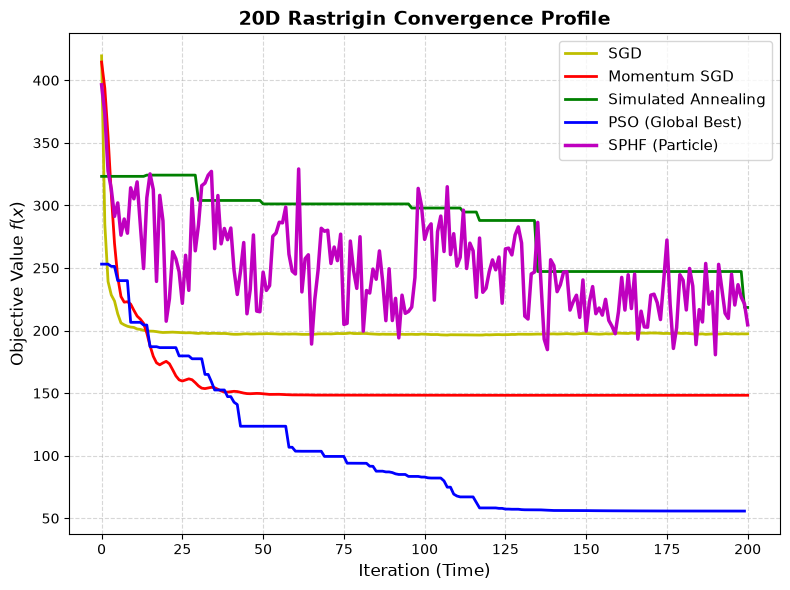

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.plot(np.asanyarray(sgd_f_r).flatten(), 'y-', label='SGD', linewidth=2)
ax.plot(np.asanyarray(msgd_f_r).flatten(), 'r-', label='Momentum SGD', linewidth=2)
ax.plot(np.asanyarray(sa_f_r).flatten(), 'g-', label='Simulated Annealing', linewidth=2)
ax.plot(np.asanyarray(pso_f_r).flatten(), 'b-', label='PSO (Global Best)', linewidth=2)
ax.plot(np.asanyarray(sphf_f_r).flatten(), 'm-', label='SPHF (Particle)', linewidth=2.5)

ax.set_xlabel('Iteration (Time)', fontsize=12)
ax.set_ylabel('Objective Value $f(x)$', fontsize=12)
ax.set_title(f'{D}D Rastrigin Convergence Profile', fontsize=14, fontweight='bold')
ax.grid(True, which="both", ls="--", alpha=0.5)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

## Bounded Elipsoid HD

We will in the end try a purely convex quadratic function, but highly ill-conditioned. The sensitivity changes drastically from one dimension to another. It is defined as 

$$f(\mathbf{x}) = \sum_{i=1}^{D} i \cdot x_i^2$$

The partial derivate are just

$$
\frac{\partial f}{\partial x_i} = 2ix_i
$$

We will constraint the search to the $[-10, 10]^D$ domain.

The minimum is $\vec 0$ and it is located in $\vec 0$.

In [18]:
def ellipsoid_hd(x):
    x = np.asarray(x)
    # Sum of i * x_i^2 (highly ill-conditioned convex function)
    coefficients = np.arange(1, x.shape[-1] + 1)
    return np.sum(coefficients * (x**2), axis=-1)

def grad_ellipsoid_hd(x):
    x = np.asarray(x)
    coefficients = np.arange(1, x.shape[-1] + 1)
    return 2 * coefficients * x

In [19]:
D = 20  # Dimensionality
n_steps = 200
x0_hd = [np.random.uniform(-10, 10, D) for _ in range (4)]
bounds_hd = [[-10, 10] for _ in range(D)]
seed = 37

# SGD
sgd_x_e, sgd_f_e = sgd(ellipsoid_hd, grad_ellipsoid_hd, x0=x0_hd[0], n_steps=n_steps, lr=0.005)

# Momentum SGD
msgd_x_e, msgd_f_e = momentum_sgd(ellipsoid_hd, grad_ellipsoid_hd, x0=x0_hd[1], n_steps=n_steps, lr=0.005)

# Simulated Annealing
sa_x_e, sa_f_e     = simulated_annealing(ellipsoid_hd, x0=x0_hd[2], bounds = bounds_hd, n_steps=n_steps, T0 = 5)

#PSO
pso_x_e, pso_f_e   = pso(ellipsoid_hd, bounds=bounds_hd, n_particles=30, n_steps=n_steps)

# SPHF
sphf_x_e, sphf_f_e = sphf(ellipsoid_hd, x0=x0_hd[3], bounds=bounds_hd, n_steps=n_steps, min_v=-1, max_v=1)

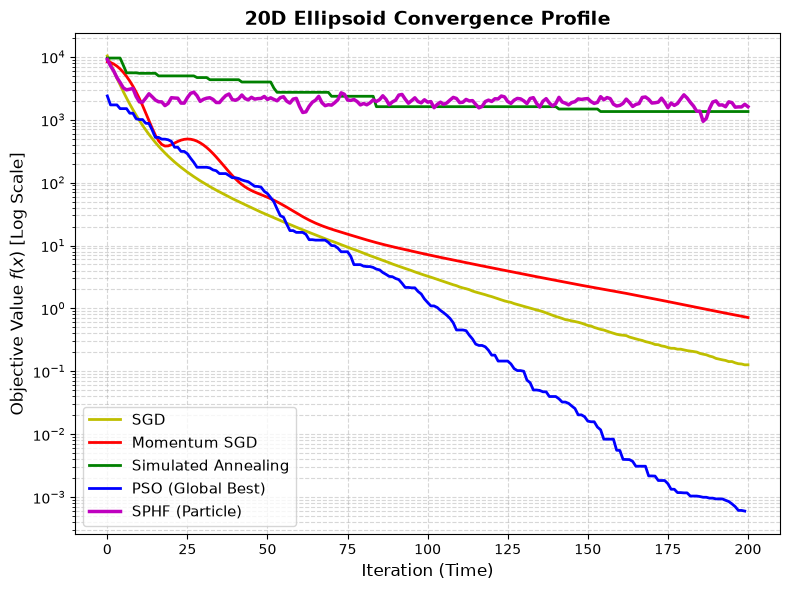

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.plot(np.asanyarray(sgd_f_e).flatten(), 'y-', label='SGD', linewidth=2)
ax.plot(np.asanyarray(msgd_f_e).flatten(), 'r-', label='Momentum SGD', linewidth=2)
ax.plot(np.asanyarray(sa_f_e).flatten(), 'g-', label='Simulated Annealing', linewidth=2)
ax.plot(np.asanyarray(pso_f_e).flatten(), 'b-', label='PSO (Global Best)', linewidth=2)
ax.plot(np.asanyarray(sphf_f_e).flatten(), 'm-', label='SPHF (Particle)', linewidth=2.5)

ax.set_yscale("log")
ax.set_xlabel('Iteration (Time)', fontsize=12)
ax.set_ylabel('Objective Value $f(x)$ [Log Scale]', fontsize=12)
ax.set_title(f'{D}D Ellipsoid Convergence Profile', fontsize=14, fontweight='bold')
ax.grid(True, which="both", ls="--", alpha=0.5)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()